C:\Users\ygunj\AppData\Local\Temp\ipykernel_25872\3490730395.py:36: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.3)


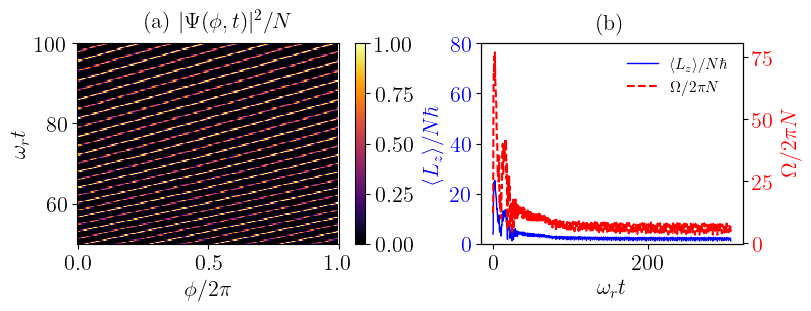

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## Reload the data

data = np.load(r"Figure_19_data.npz")

t = data["t"]
density = data["density"]
Lz = data["Lz"]
Omega = data["Omega"]

phi = data["phi"]
omega_r = data["omega_r"]
hbar = data["hbar"]

## Plotting

# ==========================================================
# LaTeX journal style
# ==========================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

# ==========================================================
# Figure setup
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plt.subplots_adjust(wspace=0.3)

# ==========================================================
# (a) Density modulation map
# ==========================================================
ax = axes[0]

PHI, T = np.meshgrid(phi, t)

im = ax.pcolormesh(
    PHI / (2 * np.pi),
    T * omega_r,
    density,
    shading="auto",
    cmap="inferno"
)

ax.set_xlabel(r"$\phi/2\pi$")
ax.set_ylabel(r"$\omega_r t$")
ax.set_ylim([50, 100])
ax.set_xticks([0, 0.5, 1])

ax.text(
    0.26, 1.08,
    r"(a) $|\Psi(\phi,t)|^2/N$",
    transform=ax.transAxes,
    fontsize=16
)

cbar = fig.colorbar(im, ax=ax, pad=0.01)

# ==========================================================
# (b) Angular momentum + angular velocity
# ==========================================================
ax1 = axes[1]

line1, = ax1.plot(
    t * omega_r,
    Lz / hbar,
    'o-',
    markersize=0.05,
    linewidth=1,
    color="blue",
    label=r"$\langle L_z \rangle/N\hbar$"
)

ax1.set_xlabel(r"$\omega_r t$")
ax1.set_ylim([0, 80])
ax1.set_ylabel(r"$\langle L_z\rangle/N\hbar$", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# right axis
ax2 = ax1.twinx()

line2, = ax2.plot(
    t * omega_r,
    Omega / (2 * np.pi),
    '--',
    color="red",
    label=r"$\Omega/2\pi N$"
)

ax2.set_ylabel(r"$\Omega/2\pi N$", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# combined legend
ax1.legend(
    [line1, line2],
    [line1.get_label(), line2.get_label()],
    loc="upper right",
    fontsize=11,
    frameon=False
)

ax1.text(
    0.5, 1.15,
    r"(b)",
    transform=ax1.transAxes,
    ha='center',
    va='top',
    fontsize=16
)

plt.show()